<a href="https://colab.research.google.com/github/Prabin-Hasham/shadenav/blob/main/notebooks/validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content
!rm -rf shadenav
!git clone https://github.com/Prabin-Hasham/shadenav.git
%cd shadenav
!pip install -q -r requirements.txt

import osmnx as ox, geopandas as gpd, networkx as nx, numpy as np
from datetime import datetime
from shadenav.shadows import shadow_at

G = ox.load_graphml("data/streets.graphml")
if G.graph["crs"] != "EPSG:32610":
    G = ox.project_graph(G)
buildings = gpd.read_file("data/buildings.gpkg")
print(G.number_of_nodes(), "nodes")

/content
Cloning into 'shadenav'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 55 (delta 22), reused 36 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 1.60 MiB | 5.45 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/shadenav
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.9/536.9 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 104.4 MB/s eta 0:00:00
1387 nodes


In [2]:
def build_samples(G, spacing_m=10):
    edges = ox.graph_to_gdfs(G, nodes=False)
    rows = []
    for (u, v, k), row in edges.iterrows():
        line = row.geometry
        n = max(int(line.length // spacing_m), 1)
        for i in range(n + 1):
            rows.append({"u": u, "v": v, "k": k,
                         "geometry": line.interpolate(i/n, normalized=True)})
    return gpd.GeoDataFrame(rows, crs=edges.crs)

def score_edges(G, samples, shadow):
    scores = {}
    if shadow is None:
        return {(u,v,k): 0.0 for u,v,k in G.edges(keys=True)}
    inside = samples.within(shadow)
    tmp = samples.assign(shaded=inside.values)
    frac = tmp.groupby(["u","v","k"])["shaded"].mean()
    for u,v,k in G.edges(keys=True):
        scores[(u,v,k)] = 1.0 - float(frac.get((u,v,k), 0.0))
    return scores

def route(G, scores, orig, dest, lam):
    for u,v,k,d in G.edges(keys=True, data=True):
        d["cost"] = d["length"] * (1 + lam * scores.get((u,v,k), 1.0))
    path = nx.shortest_path(G, orig, dest, weight="cost")
    length = sum(min(G[u][v][kk]["length"] for kk in G[u][v])
                 for u,v in zip(path[:-1], path[1:]))
    sun_m = sum(min(G[u][v][kk]["length"] * scores.get((u,v,kk),1.0) for kk in G[u][v])
                for u,v in zip(path[:-1], path[1:]))
    return length, sun_m

In [9]:
import time as _time

# Fixed seed => the SAME random routes every run. This is what lets us
# re-run on LiDAR data later and compare fairly: only the heights change,
# not the test set.
rng = np.random.default_rng(42)

nodes = list(G.nodes())
N_PAIRS = 200                       # random start/end pairs
LAMBDAS = [0, 0.1, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 5] # shade-preference values to sweep
WHEN = datetime(2025, 9, 15, 9)     # fixed time: 9am, long morning shadows

# score the streets once for this time (shadows don't depend on lambda)
samples = build_samples(G)
shadow = shadow_at(buildings, WHEN)
scores = score_edges(G, samples, shadow)
print("streets scored")

# pick 200 random origin/destination pairs, far enough apart to be meaningful
pairs = []
while len(pairs) < N_PAIRS:
    o, d = rng.choice(nodes, 2, replace=False)
    try:
        if nx.shortest_path_length(G, o, d, weight="length") > 300:  # >300m apart
            pairs.append((int(o), int(d)))
    except nx.NetworkXNoPath:
        continue
print(len(pairs), "pairs selected")

streets scored
200 pairs selected


In [10]:
rows = []
t0 = _time.time()

for i, (o, d) in enumerate(pairs):
    # baseline: shortest path (lambda=0) for THIS pair
    base_len, base_sun = route(G, scores, o, d, lam=0)
    if base_len == 0:
        continue

    for lam in LAMBDAS:
        length, sun_m = route(G, scores, o, d, lam=lam)
        rows.append({
            "pair": i,
            "lambda": lam,
            "length_m": length,
            "sun_m": sun_m,
            "extra_dist_pct": 100 * (length - base_len) / base_len,
            "sun_reduction_pct": 100 * (base_sun - sun_m) / base_sun if base_sun > 0 else 0,
        })

    if (i+1) % 50 == 0:
        print(f"{i+1}/{len(pairs)} pairs done ({_time.time()-t0:.0f}s)")

import pandas as pd
df = pd.DataFrame(rows)
print("\ndone:", len(df), "routes")
df.head(10)

50/200 pairs done (3s)
100/200 pairs done (5s)
150/200 pairs done (7s)
200/200 pairs done (10s)

done: 2200 routes


,pair,lambda,length_m,sun_m,extra_dist_pct,sun_reduction_pct
0,0,0.00,702.015858,612.394245,0.000000,0.000000
1,0,0.10,702.266958,602.089144,0.035768,1.682756
2,0,0.20,702.266958,602.089144,0.035768,1.682756
3,0,0.30,743.395325,411.959309,5.894378,32.729722
4,0,0.50,743.395325,411.959309,5.894378,32.729722
5,0,0.75,743.395325,411.959309,5.894378,32.729722
6,0,1.00,743.395325,411.959309,5.894378,32.729722
7,0,1.50,743.395325,411.959309,5.894378,32.729722
8,0,2.00,743.395325,411.959309,5.894378,32.729722
9,0,3.00,743.395325,411.959309,5.894378,32.729722


In [11]:
import folium

def to_latlon(G, path):
    nds = ox.graph_to_gdfs(G, edges=False).to_crs(4326)
    return [(nds.loc[n].geometry.y, nds.loc[n].geometry.x) for n in path]

def path_nodes(G, scores, o, d, lam):
    for u,v,k,dd in G.edges(keys=True, data=True):
        dd["cost"] = dd["length"] * (1 + lam * scores.get((u,v,k), 1.0))
    return nx.shortest_path(G, o, d, weight="cost")

# center map on the study area
ctr = ox.graph_to_gdfs(G, edges=False).to_crs(4326).geometry
m = folium.Map(location=[ctr.y.mean(), ctr.x.mean()], zoom_start=15,
               tiles="OpenStreetMap")

# draw the shadow layer for context
folium.GeoJson(
    gpd.GeoSeries([shadow], crs=buildings.crs).to_crs(4326).iloc[0],
    style_function=lambda _: {"fillColor":"#1a1a2e","color":"none","fillOpacity":0.3},
).add_to(m)

# pick a few pairs to show (change these indices to explore others)
show = [0, 5, 12, 30]
for idx in show:
    o, d = pairs[idx]
    short = path_nodes(G, scores, o, d, lam=0)
    shady = path_nodes(G, scores, o, d, lam=2)
    folium.PolyLine(to_latlon(G, short), color="#d08770", weight=4, opacity=0.8,
                    tooltip=f"pair {idx} shortest").add_to(m)
    folium.PolyLine(to_latlon(G, shady), color="#5e81ac", weight=4, opacity=0.8,
                    tooltip=f"pair {idx} shady").add_to(m)
    folium.Marker(to_latlon(G, short)[0], icon=folium.Icon(color="green")).add_to(m)
    folium.Marker(to_latlon(G, short)[-1], icon=folium.Icon(color="red")).add_to(m)

m

In [12]:
summary = df.groupby("lambda").agg(
    mean_extra_dist=("extra_dist_pct", "mean"),
    mean_sun_reduction=("sun_reduction_pct", "mean"),
    median_extra_dist=("extra_dist_pct", "median"),
    median_sun_reduction=("sun_reduction_pct", "median"),
).round(2)
print(summary)

        mean_extra_dist  mean_sun_reduction  median_extra_dist  \
lambda                                                           
0.00               0.00                0.00               0.00   
0.10               0.36               11.11               0.10   
0.20               0.86               15.01               0.43   
0.30               1.22               16.87               0.77   
0.50               2.19               19.91               1.59   
0.75               2.85               21.26               2.41   
1.00               3.48               22.19               2.94   
1.50               4.99               23.83               4.62   
2.00               5.97               24.54               5.47   
3.00               8.06               25.60               6.74   
5.00               9.99               26.25               7.19   

        median_sun_reduction  
lambda                        
0.00                    0.00  
0.10                    7.72  
0.20             

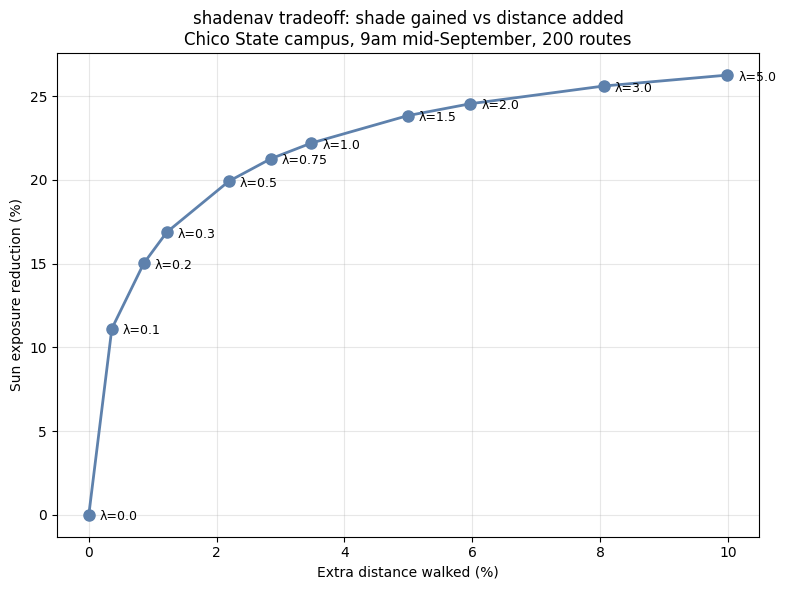

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(summary["mean_extra_dist"], summary["mean_sun_reduction"],
        "o-", color="#5e81ac", linewidth=2, markersize=8)

for lam, row in summary.iterrows():
    ax.annotate(f"λ={lam}",
                (row["mean_extra_dist"], row["mean_sun_reduction"]),
                textcoords="offset points", xytext=(8, -4), fontsize=9)

ax.set_xlabel("Extra distance walked (%)")
ax.set_ylabel("Sun exposure reduction (%)")
ax.set_title("shadenav tradeoff: shade gained vs distance added\n"
             "Chico State campus, 9am mid-September, 200 routes")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tradeoff_curve_osm.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
df.to_csv("validation_osm.csv", index=False)
summary.to_csv("validation_osm_summary.csv")
print("saved")

saved
